In [1]:
!unzip archive.zip

Archive:  archive.zip
  inflating: StudentsPerformance.csv  


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Load the cleaned dataset (or StudentsPerformance.csv)
df = pd.read_csv('cleaned_students_performance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


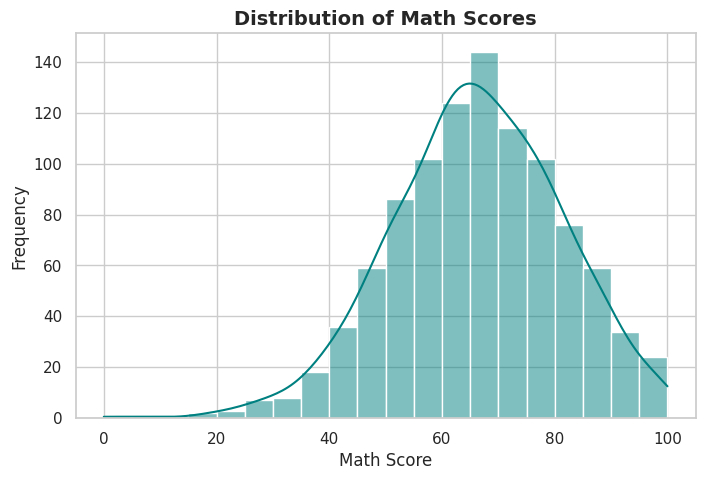

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['math score'], kde=True, color='teal', bins=20)
plt.title('Distribution of Math Scores', fontsize=14, weight='bold')
plt.xlabel('Math Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

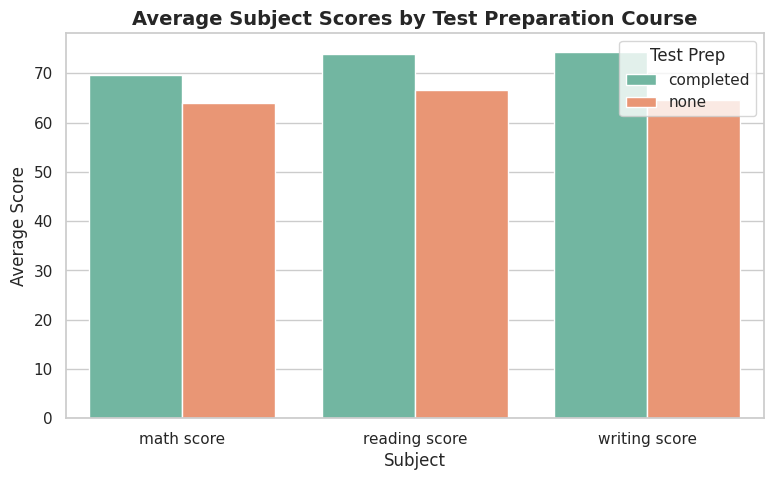

In [5]:
# Calculate average scores based on test prep course
prep_scores = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean().reset_index()
prep_melted = prep_scores.melt(id_vars='test preparation course', var_name='Subject', value_name='Average Score')

plt.figure(figsize=(9, 5))
sns.barplot(data=prep_melted, x='Subject', y='Average Score', hue='test preparation course', palette='Set2')
plt.title('Average Subject Scores by Test Preparation Course', fontsize=14, weight='bold')
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.legend(title='Test Prep')
plt.show()

/tmp/ipykernel_511/2214627576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parental level of education', y='reading score', order=education_order, palette='Pastel1')


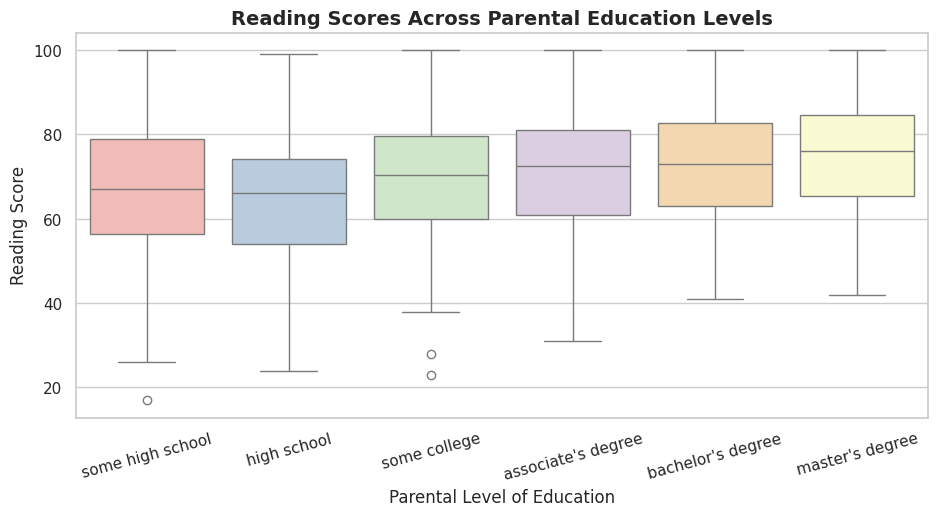

In [6]:
plt.figure(figsize=(11, 5))
education_order = [
    'some high school', 'high school', 'some college',
    "associate's degree", "bachelor's degree", "master's degree"
]
sns.boxplot(data=df, x='parental level of education', y='reading score', order=education_order, palette='Pastel1')
plt.title('Reading Scores Across Parental Education Levels', fontsize=14, weight='bold')
plt.xlabel('Parental Level of Education', fontsize=12)
plt.ylabel('Reading Score', fontsize=12)
plt.xticks(rotation=15)
plt.show()

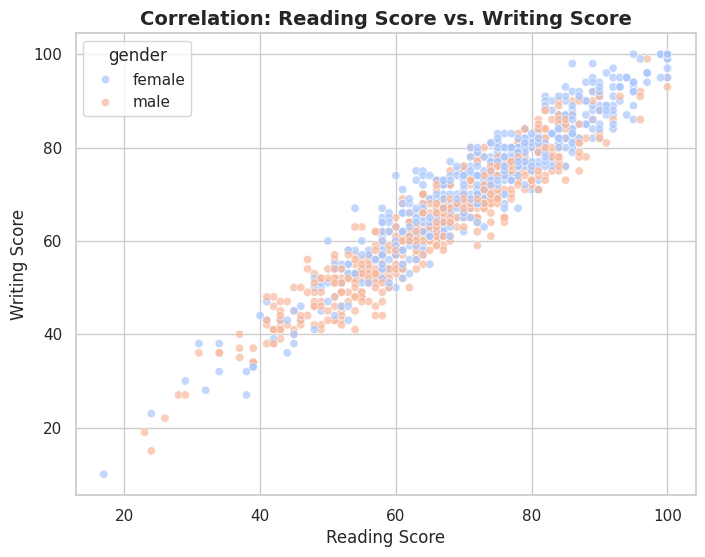

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='reading score', y='writing score', hue='gender', alpha=0.7, palette='coolwarm')
plt.title('Correlation: Reading Score vs. Writing Score', fontsize=14, weight='bold')
plt.xlabel('Reading Score', fontsize=12)
plt.ylabel('Writing Score', fontsize=12)
plt.show()

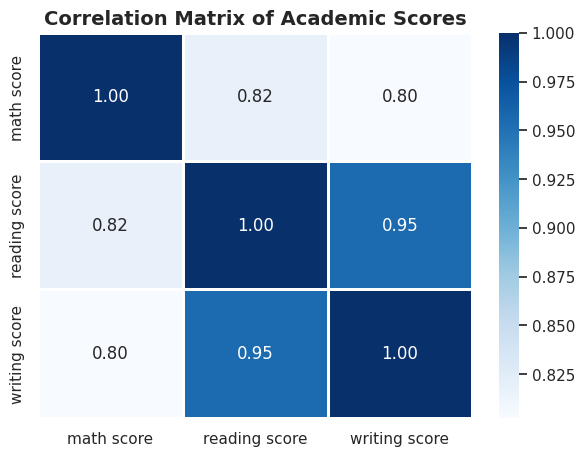

In [8]:
plt.figure(figsize=(7, 5))
numeric_cols = df[['math score', 'reading score', 'writing score']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix of Academic Scores', fontsize=14, weight='bold')
plt.show()